# ANOVA Introduction

**Module 5: Numerical Outcomes** | Lean Six Sigma Data Analytics

---

## Why ANOVA Matters

A tool as basic and intuitive as the ANOVA technique can really make a difference—helping people understand how something works (or doesn't work) and use this knowledge to make better informed decisions.

**Real example:** An ANOVA analysis showed that an underlying factor had absolutely no effect on KPIs, leading management to change their implementation policy.

ANOVA stands for **Analysis of Variance**.

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for ANOVA analysis!')

Ready for ANOVA analysis!


---

## When Do We Use ANOVA?

Remember the decision diagram for selecting the appropriate statistical technique:

**ANOVA is used when:**
- The **Y variable** is **numerical**
- The **X variable** is **categorical**

---

## Example: Coffee Factory Moisture Problem

### The Scenario

Imagine you work in a factory producing coffee and you are in charge of quality inspections.

**The process:** Raw coffee beans are roasted before they are ground and packed.

**Important quality metric:** Moisture content of the coffee beans

| Moisture Level | Problem |
|----------------|----------|
| Too much moisture | Coffee will rot very quickly |
| Too little moisture | Coffee will not taste good |

**The problem:** The moisture percentage is not always within specifications.

### The Hypothesis

There are **four different machines** in the factory. Could it be that the machine influences the moisture content of the coffee?

---

## Step 1: Collect and Organize Data

To answer the question, you collect data:
- **10 batches** from each machine
- Measure the **moisture percentage** for each batch
- Record **which machine** the batch was made on

In [2]:
# Load the moisture data
def load_moisture_wide():
    """Load moisture data in wide format (as collected from factory)"""
    df = pd.read_excel(xlsx, sheet_name='Moisture', skiprows=7, header=None, usecols=[0,1,2,3])
    df.columns = ['Machine_1', 'Machine_2', 'Machine_3', 'Machine_4']
    return df.dropna(how='all')

moisture_wide = load_moisture_wide()

print('Collected data (as measured from each machine):')
print(f'Shape: {moisture_wide.shape}')
print()
moisture_wide

Collected data (as measured from each machine):
Shape: (10, 4)



,Machine_1,Machine_2,Machine_3,Machine_4
0,11.37,9.43,11.27,8.80
1,11.31,9.62,8.47,9.58
2,10.93,6.61,11.86,12.26
3,13.77,9.31,8.77,10.00
4,14.45,14.08,8.44,8.84
5,11.80,9.56,10.63,9.49
6,12.30,10.99,13.67,10.18
7,9.45,7.05,13.02,8.77
8,12.28,11.02,12.90,10.07
9,11.47,8.88,11.72,9.30


### Data Format Problem

This dataset is **not in the correct format** for ANOVA.

Each column contains 10 measurements from each machine. But for ANOVA:
- The **X and Y variables** should have their **separate columns**
- Each **row** needs to contain **one unit** (one batch)

**Solution:** Stack the columns.

In Minitab: Data > Stack > Stack Columns

In [3]:
# Stack the data (convert from wide to long format)
# Equivalent to Minitab: Data > Stack > Stack Columns

moisture = moisture_wide.melt(var_name='Machine', value_name='Moisture_Pct').dropna()

print('Stacked data (correct format for ANOVA):')
print(f'Shape: {moisture.shape}')
print()
print('We now have two columns with 40 units.')
print('Each row contains a batch: moisture percentage and machine.')
print()
moisture.head(15)

Stacked data (correct format for ANOVA):
Shape: (40, 2)

We now have two columns with 40 units.
Each row contains a batch: moisture percentage and machine.



,Machine,Moisture_Pct
0,Machine_1,11.37
1,Machine_1,11.31
2,Machine_1,10.93
3,Machine_1,13.77
4,Machine_1,14.45
5,Machine_1,11.80
6,Machine_1,12.30
7,Machine_1,9.45
8,Machine_1,12.28
9,Machine_1,11.47


---

## Visualize the Data

This graph shows the moisture percentage per machine.

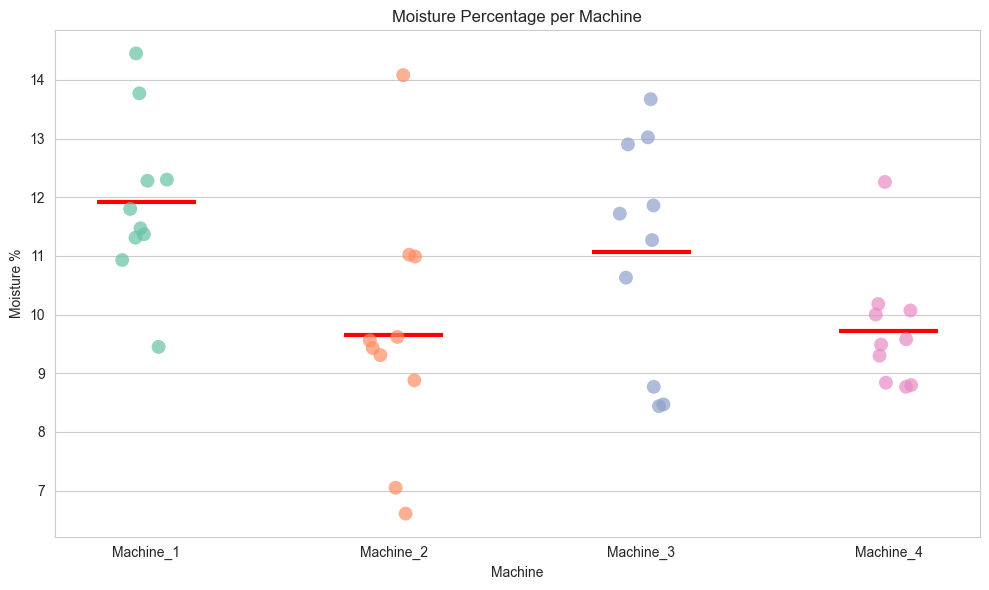

OBSERVATION:
  There appears to be a difference between the machines.
  Coffee produced on Machine_1 shows higher moisture content
  on average than coffee produced on Machine_2.


In [4]:
# Graph of moisture percentage per machine
fig, ax = plt.subplots(figsize=(10, 6))

sns.stripplot(x='Machine', y='Moisture_Pct', data=moisture, ax=ax,
              hue='Machine', palette='Set2', legend=False, size=10, alpha=0.7)

# Add mean markers
means = moisture.groupby('Machine')['Moisture_Pct'].mean()
for i, (machine, mean) in enumerate(means.items()):
    ax.hlines(mean, i-0.2, i+0.2, colors='red', linewidths=3)

ax.set_xlabel('Machine')
ax.set_ylabel('Moisture %')
ax.set_title('Moisture Percentage per Machine')

plt.tight_layout()
plt.show()

print('OBSERVATION:')
print('  There appears to be a difference between the machines.')
print(f'  Coffee produced on Machine_1 shows higher moisture content')
print(f'  on average than coffee produced on Machine_2.')

---

## How ANOVA Works

ANOVA:
1. Makes **groups** according to your categorical influence factor
2. Tests whether these groups have **equal means or not**

---

## The Key Question

We have only measured **10 data points per machine**.

- Is this enough to conclude there are differences between machines **in the whole population**?
- If we take a second sample tomorrow, will Machine 1 still give the highest moisture percentage?
- Can we **generalize** these conclusions to the entire population of batches?

To answer this, we perform a **statistical analysis** to generalize our findings from the sample.

---

## Identifying Your Variables

| Variable | Description | Type | In Our Example |
|----------|-------------|------|----------------|
| **Y** | The variable you wish to understand or explain | Numerical | Moisture % |
| **X** | The variable that potentially influences Y | Categorical | Machine |

In a Six Sigma project, Y is nearly always your **CTQ** (Critical to Quality).

**Decision:** Y is numerical, X is categorical → Use **ANOVA**

In [5]:
# Confirm variable types
print('VARIABLE IDENTIFICATION')
print('=' * 50)
print()
print('Y Variable (the variable you wish to understand):')
print('  Name: Moisture percentage')
print('  Type: Numerical')
print()
print('X Variable (the variable that potentially influences Y):')
print('  Name: Machine')
print('  Type: Categorical')
print()
print('Using the decision diagram:')
print('  Y is numerical + X is categorical --> ANOVA')

VARIABLE IDENTIFICATION

Y Variable (the variable you wish to understand):
  Name: Moisture percentage
  Type: Numerical

X Variable (the variable that potentially influences Y):
  Name: Machine
  Type: Categorical

Using the decision diagram:
  Y is numerical + X is categorical --> ANOVA


---

## The Three Steps of ANOVA

| Step | Description |
|------|-------------|
| **1** | Organize your data (X and Y in separate columns, each row = one unit) |
| **2** | Perform the ANOVA |
| **3** | Residual analysis (verify reliability of results) |

We have completed **Step 1** by stacking our data.

Steps 2 and 3 are covered in the next videos.

---

## Summary

**ANOVA** is a suitable statistical method for comparing means across various groups.

**When to use:** Y variable is numerical, X variable is categorical.

**The analysis consists of three steps:**
1. Organizing your data
2. Performing the ANOVA
3. Performing residual analysis to check if the assumptions are met